In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

**Clustering**
---

The goal in this notebook is to find different strategies that the drivers have in different race track. First K-Means is implemented.

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
clustering_data = pd.read_csv('/content/drive/MyDrive/DSA210/ML1.csv')
clustering_data.head(10)

,raceId,driverId,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,circuitId,stop_count,Track Length (km),Turns,Direction,Circuit Type
0,337,1,15.0,15,15,26.1,3,1,5.412,15,Clockwise,Race
1,337,3,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
2,337,4,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
3,337,5,30.0,30,30,26.1,3,1,5.412,15,Clockwise,Race
4,337,9,12.0,12,12,26.1,3,1,5.412,15,Clockwise,Race
5,337,13,17.0,17,17,26.1,3,1,5.412,15,Clockwise,Race
6,337,15,24.0,24,24,26.1,3,1,5.412,15,Clockwise,Race
7,337,16,15.0,15,15,26.1,3,1,5.412,15,Clockwise,Race
8,337,17,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
9,337,18,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race


**Drop Columns**

These columns are dropped since K-Means can use these values to create an connection that is not related to the goal.

---

In [ ]:
clustering_data.drop(columns=['raceId', 'circuitId', 'driverId'], inplace=True)
clustering_data.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction,Circuit Type
0,15.0,15,15,26.1,1,5.412,15,Clockwise,Race
1,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
2,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
3,30.0,30,30,26.1,1,5.412,15,Clockwise,Race
4,12.0,12,12,26.1,1,5.412,15,Clockwise,Race
5,17.0,17,17,26.1,1,5.412,15,Clockwise,Race
6,24.0,24,24,26.1,1,5.412,15,Clockwise,Race
7,15.0,15,15,26.1,1,5.412,15,Clockwise,Race
8,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
9,16.0,16,16,26.1,1,5.412,15,Clockwise,Race


**Data Transformation**

Since K-means and other unsupervised algorithms use distance to create clusters the categorical variables are converted into numeric/boolean features.

Also, the values are standarized since there are major differences between the values of Track Length and temp. Therefore, the model can be more affected by columns that have larger values.

---

In [ ]:
cluster_one_hot_encoded = pd.get_dummies(clustering_data, columns=['Direction', 'Circuit Type'])
cluster_one_hot_encoded.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False


In [ ]:
scaler = preprocessing.StandardScaler()
clustering_s = scaler.fit_transform(cluster_one_hot_encoded)
clustering_standard_encoded = pd.DataFrame(clustering_s)
clustering_standard_encoded.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.950674,-0.158218,-1.395956,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
1,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
2,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
3,0.488097,1.266475,-0.262975,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
4,-1.238428,-0.443157,-1.622552,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
5,-0.758838,0.031741,-1.244892,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
6,-0.087411,0.696597,-0.716167,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
7,-0.950674,-0.158218,-1.395956,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
8,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
9,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442


**Silhouette and Elbow Graph**

These graphs are used for finding the ideal K value for the K-means.
In this case there isn't necessarily an good elbow value. On the other hand, using the silhouette value K = 5 can be selected.

---

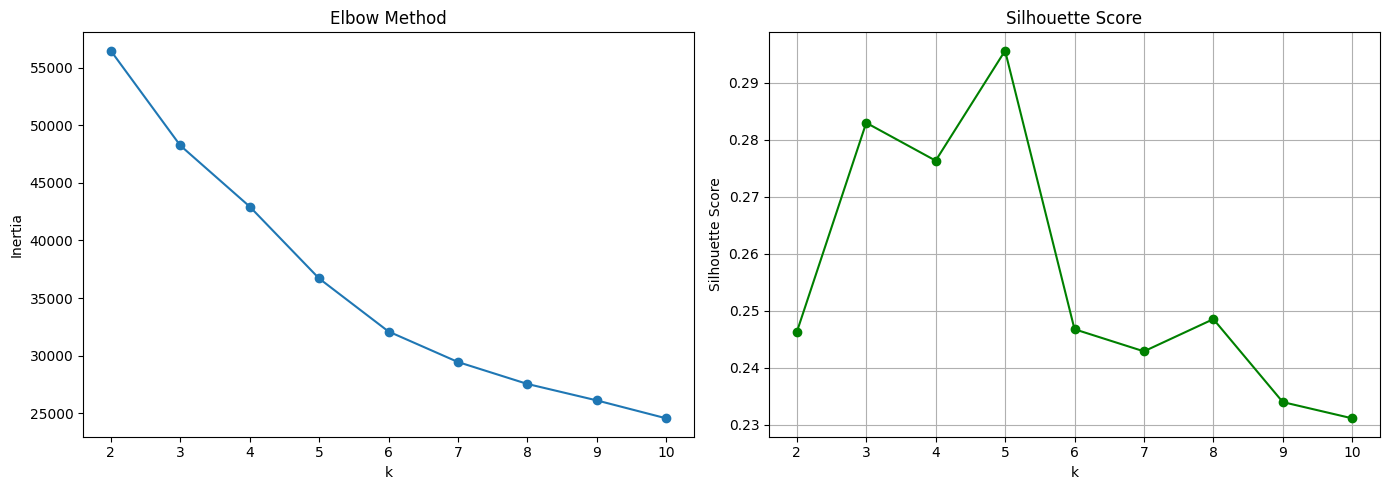

In [ ]:
inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(clustering_standard_encoded)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(clustering_standard_encoded, labels))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.grid(True)
plt.show()

**Check Clustering in 2D**

Using PCA the features can be reduced to 2 dimensions and this can be used for understanding the clusters created by the K-Means. From the graph it can be seen that three clusters overlap which is not the best outcome.


---

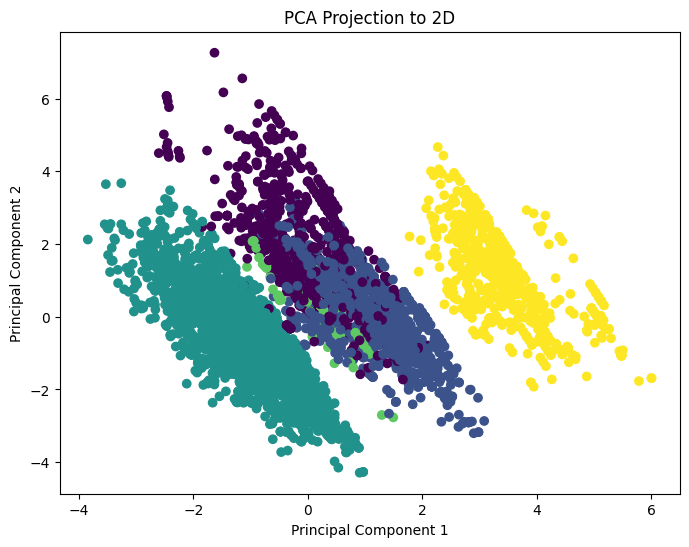

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA[:, 0], Clustering_PCA[:, 1], c=labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

In [ ]:
k_mean_result_df = cluster_one_hot_encoded.copy(deep=False)
k_mean_result_df['cluster'] = labels
k_mean_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,2
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,2
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,2
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,2
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2


In [ ]:
res = k_mean_result_df.groupby('cluster').mean().reset_index()
res.head(6)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,0,27.781288,19.523694,35.685298,17.522479,1.897934,4.277094,15.450790,0.0,1.0,0.0,0.0,1.0
1,1,24.467058,16.956679,33.384477,20.744946,1.954874,5.081307,16.853791,1.0,0.0,1.0,0.0,0.0
2,2,24.860938,15.770976,34.146053,19.443226,2.110628,5.278618,15.123990,0.0,1.0,1.0,0.0,0.0
3,3,26.850877,20.736842,32.807018,18.382456,1.543860,5.848000,18.000000,0.0,1.0,0.0,1.0,0.0
4,4,22.213650,16.626113,27.835312,25.095401,1.808605,5.538991,20.172107,1.0,0.0,0.0,0.0,1.0


**Result Analysis**

The results show that direction of the track and the circuit types are different in all of the clusters which means that model used these features primally to cluster. This can be also supported by the values in other columns not having major differences in their values. Only cluster 4 has some value differences like having higher temperature and lower last pit stop laps. Therefore, from these results it can be inferred that K-Means clusters according to the strategy followed by the majority of the drivers follow in different types of tracks.


---

**Model 2**

One possible cause of having low silhouette score in K-Means is due to clusters not following globular shapes and to check this DBSCAN is implemented. In DBSCAN there are two hyperparameters to estimate which are minPts and eps.

“minPts is selected based on the domain knowledge. If you do not have domain understanding, a rule of thumb is to derive minPts from the number of dimensions D in the data set. minPts >= D + 1. For 2D data, take minPts = 4. For larger datasets, with much noise, it suggested to go with minPts = 2 * D.” (Pratik Nabriya, 2020).

The current data contains 12 features therefore the range [4, 24] was selected for the minPts.

“One way to find the best ε  for DBSCAN is to compute the knn, then sort the distances and see where the "knee" is located.” (luisfelipe18, 2021).  

Therefore, for each minPts in the range this method is applied.

In the elbow graph, elbow points were similar therefore X = 5500 is selected.

(Reference List can be found at the end of the Notebook and in Final Report)

---

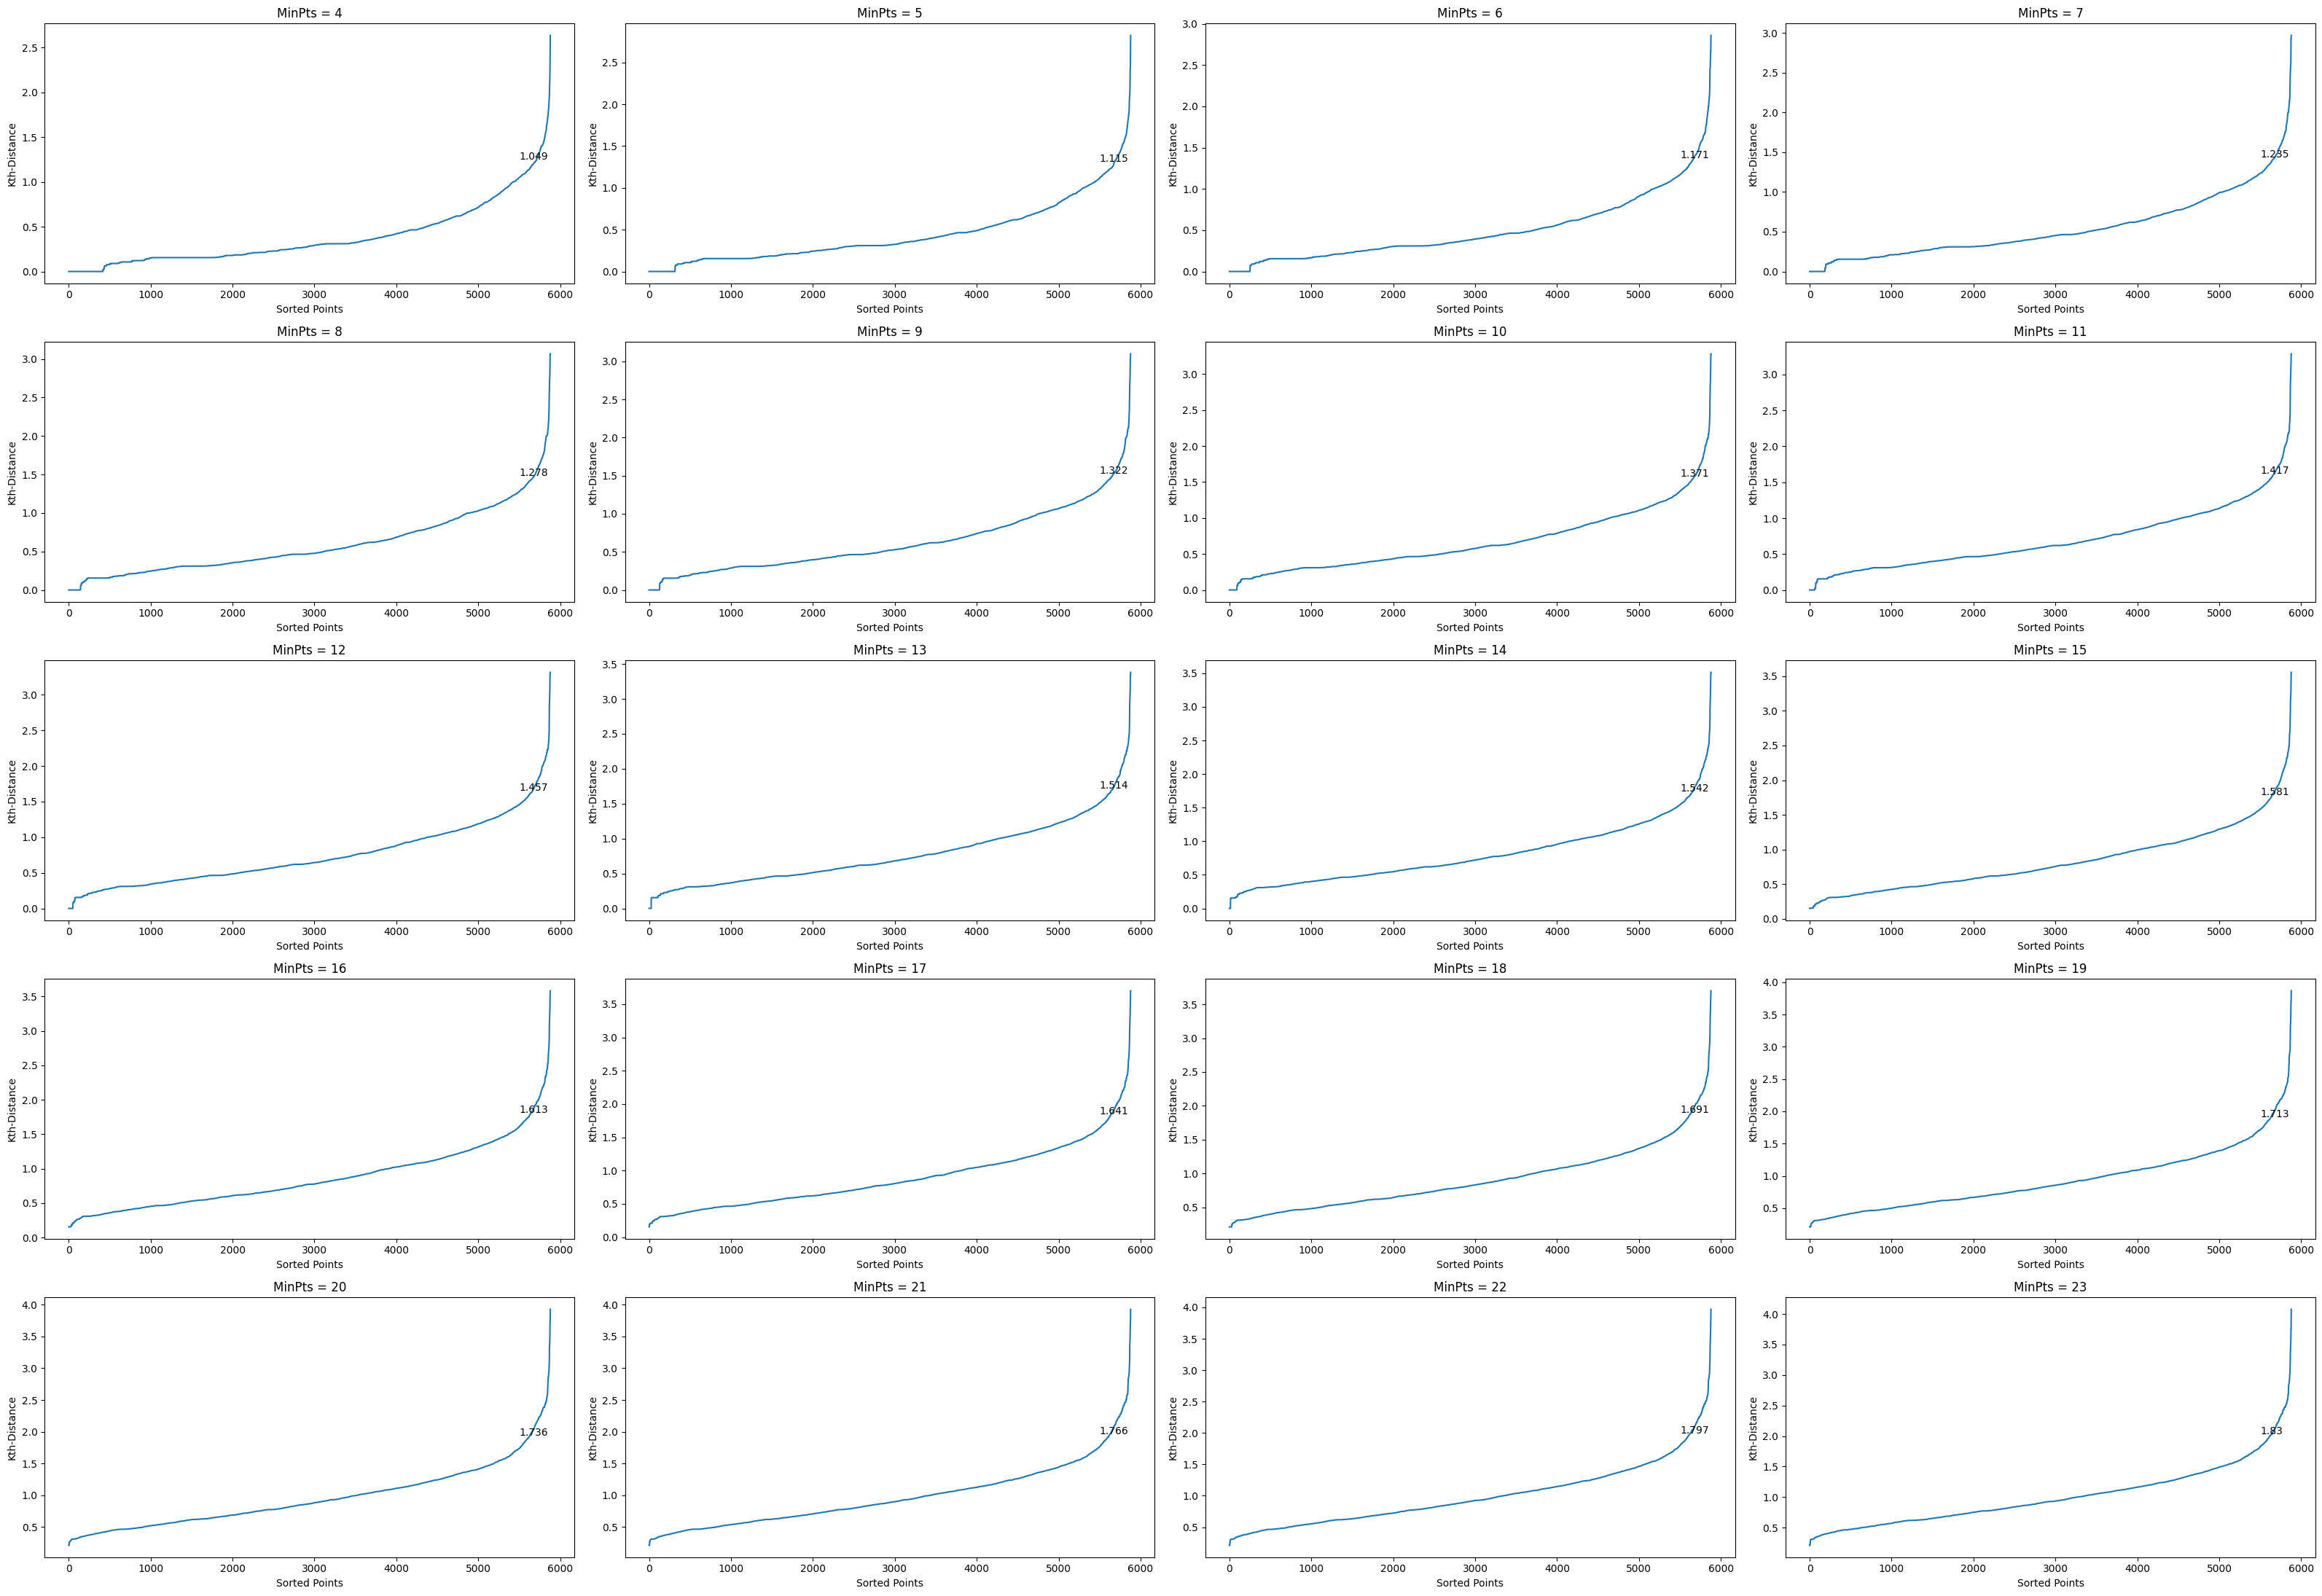

In [ ]:
dimension = 12
fig, ax = plt.subplots(nrows=5, ncols=4, figsize=(32,22))
row = 0
col = 0
idx = 5500
eps_pts_tuple = []
for i in range(4, (2*dimension)):
  nbrs = NearestNeighbors(n_neighbors=i, algorithm='auto').fit(clustering_standard_encoded)
  distances, indices = nbrs.kneighbors(clustering_standard_encoded)
  kth_distance_sorted = np.sort(distances[:, i-1])
  eps = kth_distance_sorted[idx]
  temp = (round(eps, 4), i)
  eps_pts_tuple.append(temp)

  ax[row, col].plot(kth_distance_sorted)
  ax[row, col].set_xlabel("Sorted Points")
  ax[row, col].set_ylabel("Kth-Distance")
  ax[row, col].set_title(f'MinPts = {i}')
  ax[row, col].annotate(round(eps, 3), xy=(idx, eps + 0.2))

  if(col == 3):
    row += 1
    col = 0
  else:
    col += 1

plt.tight_layout()
plt.show()


In [ ]:
print(eps_pts_tuple)

[(np.float64(1.0487), 4), (np.float64(1.1152), 5), (np.float64(1.1709), 6), (np.float64(1.2347), 7), (np.float64(1.2775), 8), (np.float64(1.3221), 9), (np.float64(1.3706), 10), (np.float64(1.4174), 11), (np.float64(1.4571), 12), (np.float64(1.5142), 13), (np.float64(1.5418), 14), (np.float64(1.5815), 15), (np.float64(1.6127), 16), (np.float64(1.6413), 17), (np.float64(1.6914), 18), (np.float64(1.7126), 19), (np.float64(1.7358), 20), (np.float64(1.7657), 21), (np.float64(1.7968), 22), (np.float64(1.8298), 23)]


**Results**

In the 4 – 12 the number of clusters decrease, and silhouette scores increase. However, in 12 – 16 and after 17, the models are stuck on similar number of clusters, and their silhouette scores do not increase. Since minPts = 17 has the highest silhouette score it is selected.


---

In [ ]:
for eps, minpts in eps_pts_tuple:
  dbscan_cluster = DBSCAN(eps=eps, min_samples=minpts)
  dbscan_labels = dbscan_cluster.fit_predict(clustering_standard_encoded)

  n_clusters = len(set(dbscan_labels))

  score = silhouette_score(clustering_standard_encoded, dbscan_labels)
  print(f"Distance={eps}, Min number of Points={minpts}, Number of clusters= {n_clusters}, Silhouette Score: {round(score, 3)}")


Distance=1.0487, Min number of Points=4, Number of clusters= 45, Silhouette Score: 0.024
Distance=1.1152, Min number of Points=5, Number of clusters= 32, Silhouette Score: 0.075
Distance=1.1709, Min number of Points=6, Number of clusters= 27, Silhouette Score: 0.087
Distance=1.2347, Min number of Points=7, Number of clusters= 22, Silhouette Score: 0.106
Distance=1.2775, Min number of Points=8, Number of clusters= 20, Silhouette Score: 0.101
Distance=1.3221, Min number of Points=9, Number of clusters= 17, Silhouette Score: 0.151
Distance=1.3706, Min number of Points=10, Number of clusters= 16, Silhouette Score: 0.188
Distance=1.4174, Min number of Points=11, Number of clusters= 13, Silhouette Score: 0.196
Distance=1.4571, Min number of Points=12, Number of clusters= 13, Silhouette Score: 0.216
Distance=1.5142, Min number of Points=13, Number of clusters= 12, Silhouette Score: 0.218
Distance=1.5418, Min number of Points=14, Number of clusters= 12, Silhouette Score: 0.219
Distance=1.5815,

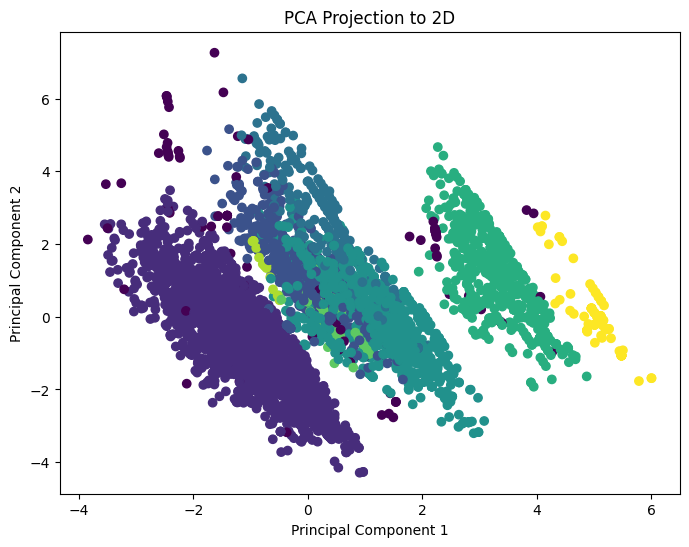

In [ ]:
eps = 1.6413
pts = 17
dbscan_cluster = DBSCAN(eps=eps, min_samples=pts)
dbscan_labels = dbscan_cluster.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA_db = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA_db[:, 0], Clustering_PCA_db[:, 1], c=dbscan_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

**Graph Analysis**

From the PCA 2D graph it can be seen that there are still many overlaps between the clusters.

---

In [ ]:
DBSCAN_result_df = cluster_one_hot_encoded.copy(deep=False)
DBSCAN_result_df['cluster'] = dbscan_labels
DBSCAN_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,0
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,0
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,0
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,0
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,0
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,0
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0


In [ ]:
res_dbscan = DBSCAN_result_df.groupby('cluster').mean().reset_index()
res_dbscan.head(10)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,-1,38.820000,13.960000,47.510000,18.533000,3.860000,5.115330,16.790000,0.45,0.55,0.26,0.06,0.68
1,0,24.814977,15.758814,34.068643,19.448924,2.101716,5.279365,15.126677,0.00,1.00,1.00,0.00,0.00
2,1,24.571285,17.098394,33.813253,17.154618,1.925703,4.802928,13.481928,0.00,1.00,0.00,0.00,1.00
3,2,29.377163,23.529412,35.425606,18.362976,1.574394,3.337000,19.000000,0.00,1.00,0.00,0.00,1.00
4,3,24.524201,17.042009,33.486758,20.864566,1.940639,5.080842,16.850228,1.00,0.00,1.00,0.00,0.00
5,4,22.810127,17.376130,28.815552,24.844846,1.752260,5.432081,19.066908,1.00,0.00,0.00,0.00,1.00
6,5,24.097222,21.611111,26.583333,19.611111,1.250000,5.848000,18.000000,0.00,1.00,0.00,1.00,0.00
7,6,37.433333,25.733333,49.133333,14.800000,2.000000,5.848000,18.000000,0.00,1.00,0.00,1.00,0.00
8,7,16.191011,15.089888,17.494382,26.807865,1.370787,6.174000,27.000000,1.00,0.00,0.00,0.00,1.00


**Clustering Analysis**

From the graph it can be seen that again the direction and circuit types are mostly different in the clusters. In the clusters that have same direction and circuit type values, there are significant differences in other columns. For instance, in clusters 1 and 2 there are differences in the first pit stop laps and number of turns. Another example would be clusters 4 and 7 where number of turns and last pit stop laps are different. Therefore, from these results it can be inferred that DBSCAN created the majority strategy that the drivers follow in different types of tracks.

---

**Model 3**

This term I’m currently taking IE451 (Data Analytics & Optimization) course and in this course, I learned a new clustering method which is called Gaussian Mixture Model (GMM).

“ GMMs are commonly used for clustering and density estimation, since they can capture complex, multimodal distributions where data points may naturally group around different centers rather than a single mean.” (Noble, n.d.).  

Therefore, this model is also developed to check whether the silhouette scores can improve, and different clusters can be obtained. It has one hyperparameter number of components, and it selected according to the silhouette score.

(Reference List can be found at the end of the Notebook and in Final Report)

---

**Evaluation Method**

Silhouette scores were used to select the number of components value in GMM.

---

In [ ]:
k_values = range(2, 10)
silhouette_values = []
for k in k_values:
    GMM = GaussianMixture(n_components=k, random_state=42, n_init=10)
    GMM_labels = GMM.fit_predict(clustering_standard_encoded)
    score = silhouette_score(clustering_standard_encoded, GMM_labels)
    print(f"Silhouette Score for k = {k} is: {score}")
    silhouette_values.append(score)


Silhouette Score for k = 2 is: 0.2809027735899079
Silhouette Score for k = 3 is: 0.2829527958528849
Silhouette Score for k = 4 is: 0.26751835593970347
Silhouette Score for k = 5 is: 0.28799798434352575
Silhouette Score for k = 6 is: 0.22747786149753105
Silhouette Score for k = 7 is: 0.1998149597056231
Silhouette Score for k = 8 is: 0.18620940388981747
Silhouette Score for k = 9 is: 0.1688305734581334


**Evaluation**

The highest silhouette score was when K = 5 therefore it is selected.

---

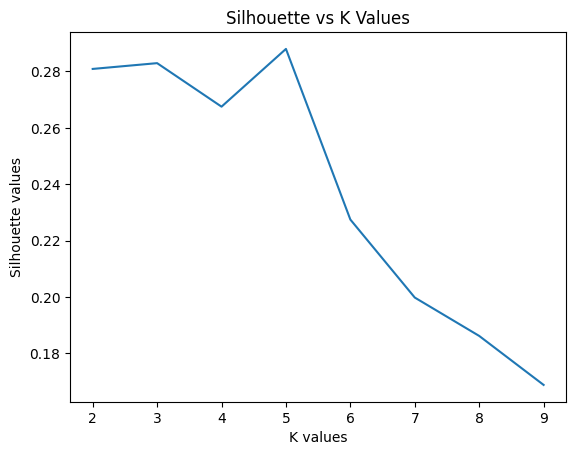

In [ ]:
plt.plot(k_values, silhouette_values)
plt.xlabel('K values')
plt.ylabel('Silhouette values')
plt.title("Silhouette vs K Values")
plt.show()

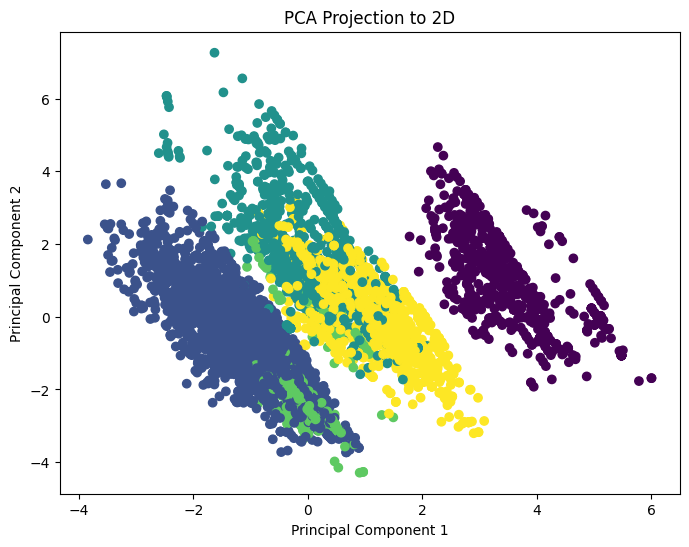

In [ ]:
GMM = GaussianMixture(n_components=5, random_state=42, n_init=10)
GMM_labels = GMM.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA_db = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA_db[:, 0], Clustering_PCA_db[:, 1], c=GMM_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

In [ ]:
GMM_result_df = cluster_one_hot_encoded.copy(deep=False)
GMM_result_df['cluster'] = GMM_labels
GMM_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,1
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,1
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,1
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,1
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,1
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,1
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,1
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,1
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,1
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,1


In [ ]:
res_gmm = GMM_result_df.groupby('cluster').mean().reset_index()
res_gmm.head(5)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,0,22.213650,16.626113,27.835312,25.095401,1.808605,5.538991,20.172107,1.0,0.0,0.000000,0.000000,1.0
1,1,25.475932,16.156949,34.968475,19.905559,2.128475,5.121872,14.771864,0.0,1.0,1.000000,0.000000,0.0
2,2,27.781288,19.523694,35.685298,17.522479,1.897934,4.277094,15.450790,0.0,1.0,0.000000,0.000000,1.0
3,3,19.627692,13.138462,26.446154,15.060615,1.849231,6.801255,18.824615,0.0,1.0,0.824615,0.175385,0.0
4,4,24.467058,16.956679,33.384477,20.744946,1.954874,5.081307,16.853791,1.0,0.0,1.000000,0.000000,0.0


**Analysis of the Results**

From these results it can be seen that the direction and circuit type were again the primary features for creating the clusters. However, one important distinction is that it categorized the road circuit and race circuits in the same category rather than creating separate clusters.


---

**References**

luisfelipe18. (2021, August 25). *Maybe a bit late, but I would like to add an answer here for future knowledge.* [Comment on the online forum post *A routine to choose eps and minPts for DBSCAN*]. Cross Validated. https://stats.stackexchange.com/a/541340

Noble, J. (n.d.). *What is a gaussian mixture model?.* IBM. https://www.ibm.com/think/topics/gaussian-mixture-model

Pratik Nabriya. (2020, July 23). *minPts is selected based on the domain knowledge.* [Comment on the online forum post *A routine to choose eps and minPts for DBSCAN*]. Cross Validated. https://stats.stackexchange.com/a/478681

